In [1]:
import cloelite
import numpyro
from numpyro import distributions as dist, infer
import jax.numpy as np
import jax
import matplotlib.pyplot as plt
import arviz

/home/marcobonici/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
instance = cloelite.jax.JAXBackground(67, 0.05, 0.27, 0.1, 3, 0.96, -1.2, 0.2, 0.55)

In [3]:
instance.comoving_distance(3)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Array(6406.637, dtype=float32)

In [4]:
zs = np.linspace(0, 5, 100)
data = instance.comoving_distance(zs)
cov = np.eye(100)*100

In [5]:
np.diagonal(cov)

Array([100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100., 100., 100., 100., 100., 100., 100., 100., 100., 100., 100.,
       100.], dtype=float32)

<ErrorbarContainer object of 3 artists>

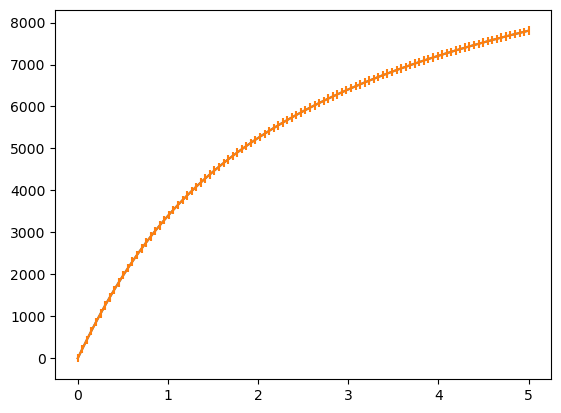

In [6]:
plt.plot(zs, data)
plt.errorbar(zs, data, yerr=np.diagonal(cov))

In [7]:
def theory(zs, Omb, w, H0):
    # These are the parameters that we're fitting and we're required to define explicit
    # priors using distributions from the numpyro.distributions module.
    instance.Omb = Omb
    instance.w = w
    instance.H0 = H0

    return instance.comoving_distance(zs)

def theory_sum(Omb, w, H0):
    return np.sum(theory(zs, Omb, w, H0))

In [8]:
theory(zs, 0.05, -1, 67.)

Array([   0.    ,  222.6579,  438.6169,  647.867 ,  850.4592, 1046.4922,
       1236.1017, 1419.4506, 1596.7213, 1768.1099, 1933.8208, 2094.063 ,
       2249.046 , 2398.9788, 2544.066 , 2684.509 , 2820.5032, 2952.2368,
       3079.8918, 3203.6433, 3323.6577, 3440.0967, 3553.1118, 3662.8496,
       3769.4487, 3873.042 , 3973.754 , 4071.705 , 4167.0083, 4259.7725,
       4350.1   , 4438.089 , 4523.831 , 4607.4146, 4688.924 , 4768.4395,
       4846.035 , 4921.784 , 4995.756 , 5068.013 , 5138.62  , 5207.6367,
       5275.118 , 5341.119 , 5405.689 , 5468.8813, 5530.7383, 5591.306 ,
       5650.6294, 5708.7466, 5765.6978, 5821.5215, 5876.2515, 5929.922 ,
       5982.569 , 6034.22  , 6084.9077, 6134.6606, 6183.506 , 6231.471 ,
       6278.5815, 6324.861 , 6370.3345, 6415.0234, 6458.951 , 6502.1367,
       6544.6025, 6586.367 , 6627.4487, 6667.866 , 6707.6377, 6746.7783,
       6785.304 , 6823.235 , 6860.579 , 6897.358 , 6933.5806, 6969.2617,
       7004.416 , 7039.0566, 7073.194 , 7106.841 , 

In [9]:
theory_sum(0.05, 0.27, 67.)

Array(314843.06, dtype=float32)

In [10]:
jax.grad(theory_sum)(0.05, 0.27, 67)

Array(73052.95, dtype=float32, weak_type=True)

In [42]:
def model(data, cov):
    # These are the parameters that we're fitting and we're required to define explicit
    # priors using distributions from the numpyro.distributions module.
    H0 = numpyro.sample("H0", dist.Uniform(60., 80.))
    Omb = numpyro.sample("Omb", dist.Uniform(0.01, 0.1))# = numpyro.deterministic("m", jnp.tan(theta))
    w = numpyro.sample("w", dist.Uniform(-2, 0.))#numpyro.sample("Omc", dist.Uniform(0.01, 0.99))# = numpyro.deterministic("m", jnp.tan(theta))
    theory_vec = theory(zs, Omb, w, H0)
    #print(H0)

    numpyro.sample("data", dist.MultivariateNormal(theory_vec, cov), obs=data)

In [43]:
sampler = infer.MCMC(
    infer.NUTS(model),
    num_warmup=500,
    num_samples=2000,
    num_chains=8,
    progress_bar=True,
)

/tmp/ipykernel_89038/400252338.py:1: UserWarning: There are not enough devices to run parallel chains: expected 8 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(8)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  sampler = infer.MCMC(


In [44]:
sampler.run(jax.random.PRNGKey(42), data, cov)

sample: 100%|██████████| 2500/2500 [01:17<00:00, 32.39it/s, 63 steps of size 2.76e-02. acc. prob=0.93] 


In [45]:
inf_data = arviz.from_numpyro(sampler)
arviz.summary(inf_data)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
H0,67.020,0.367,66.361,67.743,0.007,0.005,2436.0,2629.0,1.0
Omb,0.050,0.003,0.044,0.055,0.000,0.000,2563.0,2760.0,1.0
w,-1.202,0.030,-1.257,-1.146,0.001,0.000,2607.0,3026.0,1.0


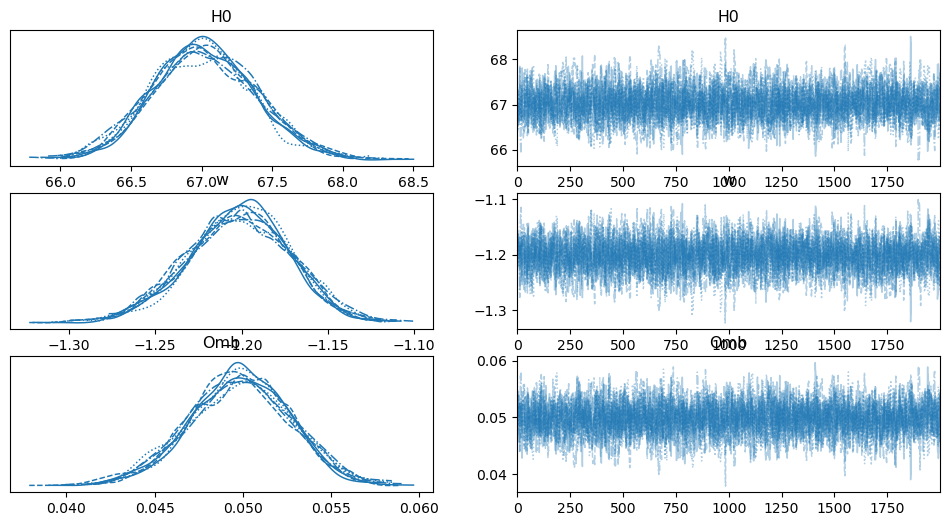

In [46]:
arviz.plot_trace(inf_data, var_names=("H0", "w",  "Omb"))

plt.show()
